<a href="https://colab.research.google.com/github/sanchezmerinomiguelangel-sudo/Procesos-Estoc-sticos/blob/main/Copia_de_GPs_PRADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio: simular y visualizar GPs

El objetivo es aprender a simular trayectorias de un GP, usando algunas de las herramientas más habituales de _machine learning_ (las que hemos visto: Python, Numpy, matplotlib). Como resultado final, generaremos las imágenes vistas en las diapositivas.

**Nota:** Si escribís sobre este notebook que os comparto, vuestros cambios no se guardarán (porque solo tenéis permisos de lectura). Igual que con el PAS, tendréis que crear una copia vuestra ("Archivo > Guardar una copia en Drive").

In [ ]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Muestras de una normal multivariante / multidimensional

Puesto que simular trayectorias de un GP involucra simular de una normal multivariante, veamos primero cómo hacer esto.

En la siguiente celda se deben obtener 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Para ello, utiliza la función `np.random.multivariate_normal` (busca en internet cómo usarla).

Además, visualiza el resultado obtenido, así como su shape.

In [ ]:
# COMPLETAR!

vector_medias = np.zeros(3)
matriz_covarianzas = np.identity(3)
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[-0.71787997 -0.97765952  1.97754079]
 [-0.43109792 -0.09393973 -1.12375289]
 [-1.93183788 -0.55991733  1.75770466]
 [-0.89482499 -0.18836883 -1.33354795]
 [ 0.43226983 -0.68721077 -0.72497624]
 [-0.56847542 -0.30384594  0.39432246]
 [-0.37468699 -0.44418819 -0.99611255]
 [-1.43286896 -1.70603416  0.29646387]
 [ 0.54853858 -1.82090423 -0.88383375]
 [ 0.49680139 -1.21883158 -0.80137059]
 [-1.4950783  -0.15911254 -0.30069903]
 [-0.85893712  1.03334061  1.38578485]
 [ 1.5107813   1.90862955 -0.42421879]
 [ 0.47105105  0.35547695 -0.81833108]
 [-1.61382678 -0.21746263  0.61922324]
 [-1.34961945  0.60442377 -1.50572099]
 [-0.35829442 -0.41710935  1.33804836]
 [-0.94594444  2.74862208  0.57775167]
 [ 0.04571563 -1.74408611  0.62695453]
 [-0.31417408 -0.31461925  0.97072303]
 [-0.72170834 -0.23358267  0.75724687]
 [-0.30290893 -1.28611193  0.870822  ]
 [-0.35673306  1.19611399 -1.66589915]
 [ 1.09934018 -0.32758191 -1.34362102]
 [ 1.0939428   0.50261591  1.05509473

Haz ahora lo mismo pero para una normal con matriz de covarianzas que no sea la identidad, sino por ejemplo $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

Puedes simplificar algo el código si usas la función `np.diag`.

¿Qué diferencias esperarías ver en las muestras obtenidas?


In [ ]:
# COMPLETAR!

vector_medias = np.zeros(3)
matriz_covarianzas = np.diag([1,10,100])
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[  1.06967787  -1.49955978   4.23307901]
 [ -0.15816796  -3.79511264  -4.77146221]
 [ -0.41242111  -0.42222575  -7.43849576]
 [ -0.08894797  -1.76060351 -15.12467452]
 [  0.44180777  -0.61199157  11.96770256]
 [ -2.10539371   0.88910886   3.06250295]
 [  1.40339612  -6.7327574   -3.36602408]
 [  0.04234895  -0.4855468   14.93913378]
 [  0.98612369  -3.33667584  12.46849947]
 [  0.48825972  -1.43424645  -9.12206506]
 [  0.37827337   0.1181113    2.20568646]
 [  0.27199561  -1.43668554  -6.41526835]
 [  1.93495378  -4.46813756   3.61192969]
 [  0.15430802  -0.96704777   7.57215559]
 [ -0.58298524   4.42576471  -9.68001813]
 [ -0.08582013  -1.11593316  17.8807817 ]
 [ -0.91181912   2.93577578  -1.37238199]
 [ -0.10320841  -2.27527806 -14.58606057]
 [  1.64887425  -5.58975457   1.32133403]
 [  0.57918056   3.98737527   7.08737611]
 [  0.04384213   0.6235849   -2.05321585]
 [ -0.73121298   0.46888085  -5.23407523]
 [  0.33955116  -2.92680883  -1.87939661]
 [  0.6

## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permita simular de un GP con kernel RBF. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

En el punto 5 se explicará la manera más limpia de usar otras funciones de medias. También se comentará la manera más adecuada para pasar el kernel como argumento de la función. Es decir, de modo que no sea necesario definir `simular_GP_RBF`, sino simplemente `simular_GP` (y que el kernel se pase como argumento de la función). Todo ello necesita del concepto de _clases_, algo que (creo) no se estudia en el grado en matemáticas.

Definimos la función principal:

In [ ]:
  # COMPLETAR

def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
    """
    Simular un GP con kernel RBF.

    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    sigma_sq: varianza del kernel. Float.
    lengthscale: parámetro de escala del kernel. Float.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).
    """
    # Paso 1: calcula el vector de medias. No uses bucles for, puedes usar np.zeros_like
    vector_medias = np.zeros_like(t)

    # Paso 2: calcula la matriz de covarianzas. No uses bucles for, utiliza la vectorización de numpy y en particular la idea de broadcasting que se comentó en la intro a numpy.

    d = (t[:, np.newaxis] - t[np.newaxis, :]) #Cogemos el vector t y creamos dos vectores nx1 y 1xn, y lo que hace numpy es estirar los vectores a nxn para que se puedan restar.

    matriz_covs = sigma_sq*np.exp(-(d**2)/(2*(lengthscale)**2))

    # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal

    samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

    return samples

Ahora utilizamos esta función para generar imágenes similares a las de las diapositivas 59 y 62.

Para ello, genera las trayectorias con la función recién definida, `simular_GP_RBF`, y píntalas con `plt.plot`

Opcional: si quieres tener diferentes ejes (subplots) en la misma figura, como se hace en las diapositivas 59 y 62, puedes mirar cómo usar `plt.subplots`.

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_455/762603505.py:13: SyntaxWarning: invalid escape sequence '\s'
  plt.title('$\sigma=0.25$')
/tmp/ipykernel_455/762603505.py:25: SyntaxWarning: invalid escape sequence '\s'
  plt.title('$\sigma=1$')
/tmp/ipykernel_455/762603505.py:37: SyntaxWarning: invalid escape sequence '\s'
  plt.title('$\sigma=4$')


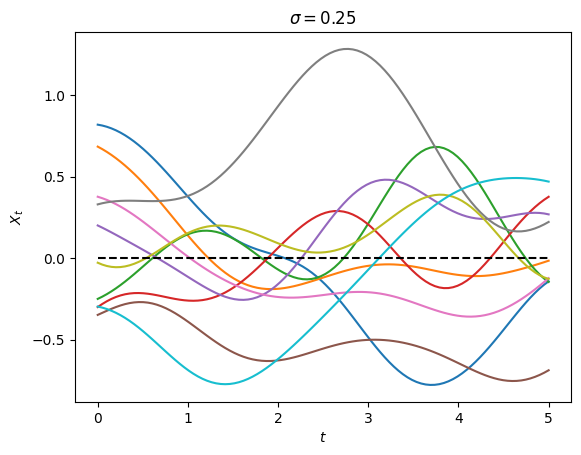

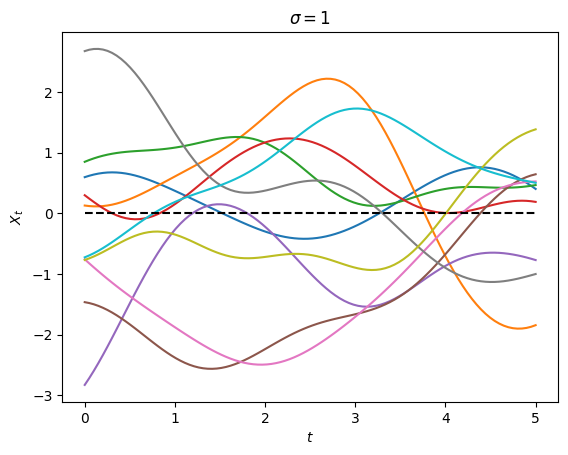

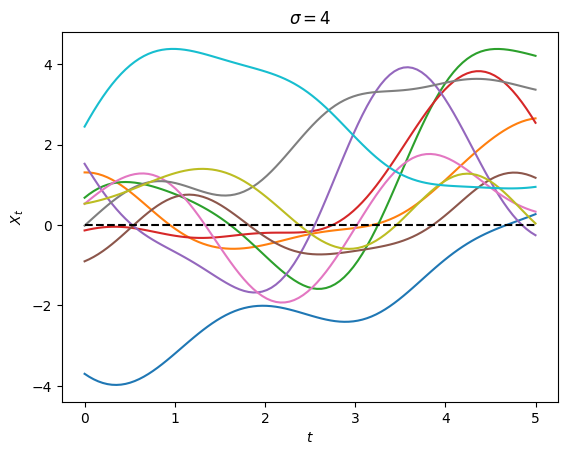

In [ ]:

# COMPLETAR (PARA LA DIAPOSITIVA 59)

#Simulamos los procesos gaussianos variando el sigma

t = np.linspace(0,5,100)

#sigma=0.25

muestras = simular_GP_RBF(t,0.25,1,10)

plt.plot(t,muestras.T)
plt.plot(t,np.zeros_like(t),color='black',linestyle='--')
plt.title('$\sigma=0.25$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()


#sigma=1

muestras = simular_GP_RBF(t,1,1,10)

plt.plot(t,muestras.T)
plt.plot(t,np.zeros_like(t),color='black',linestyle='--')
plt.title('$\sigma=1$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()


#sigma=4

muestras = simular_GP_RBF(t,4,1,10)

plt.plot(t,muestras.T)
plt.plot(t,np.zeros_like(t),color='black',linestyle='--')
plt.title('$\sigma=4$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()


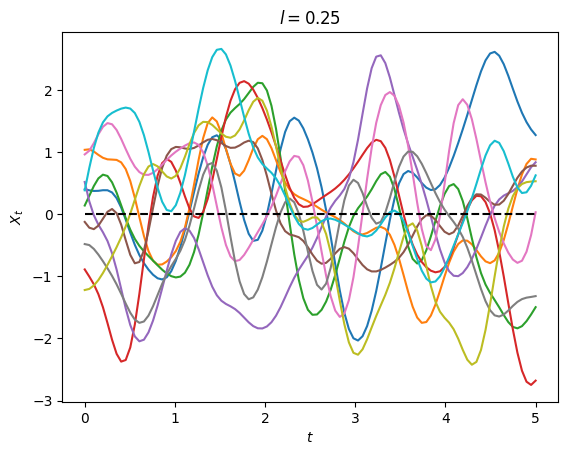

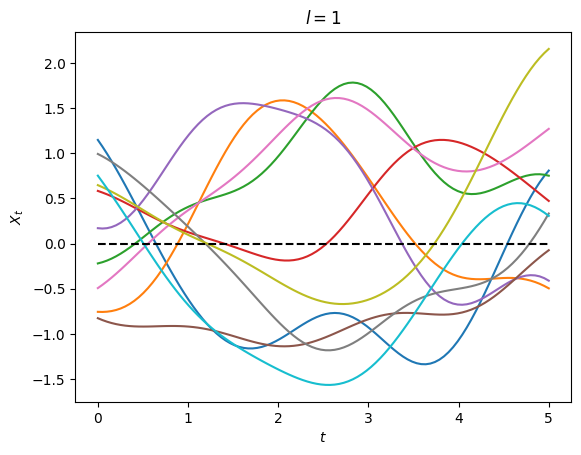

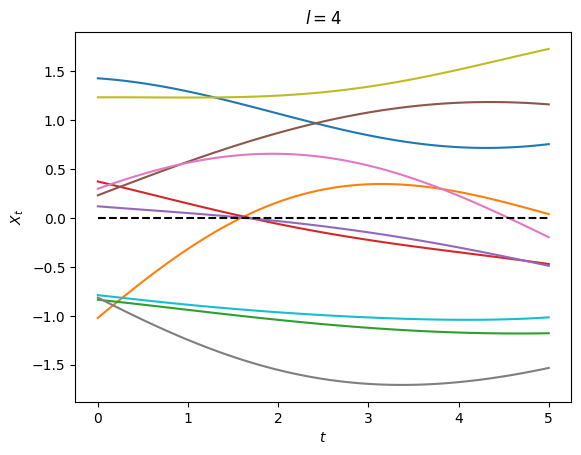

In [ ]:
# COMPLETAR (PARA LA DIAPOSITIVA 62)

#Simulamos los procesos gaussianos variando el l

t = np.linspace(0,5,100)

#l=0.25

muestras = simular_GP_RBF(t,1,0.25,10)

plt.plot(t,muestras.T)
plt.plot(t,np.zeros_like(t),color='black',linestyle='--')
plt.title('$l=0.25$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()


#l=1

muestras = simular_GP_RBF(t,1,1,10)

plt.plot(t,muestras.T)
plt.plot(t,np.zeros_like(t),color='black',linestyle='--')
plt.title('$l=1$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()


#l=4

muestras = simular_GP_RBF(t,1,4,10)

plt.plot(t,muestras.T)
plt.plot(t,np.zeros_like(t),color='black',linestyle='--')
plt.title('$l=4$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()

## 3. Simular un GP con kernel periódico

En esta sección vamos a definir una función `simular_GP_periodic` que nos permita simular de un GP con kernel periódico. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [ ]:
# COMPLETAR

def simular_GP_periodic(t, sigma_sq=1, lengthscale=1, periodo=1, num_samples=1):
    """
    Simular un GP con kernel periódico.

    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    sigma_sq: varianza del kernel. Float.
    lengthscale: parámetro de escala del kernel. Float.
    periodo: período del kernel. Float.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).
    """
    # Paso 1: calcula el vector de medias. No uses bucles for, puedes usar np.zeros_like
    vector_medias = np.zeros_like(t)

    # Paso 2: calcula la matriz de covarianzas. No uses bucles for, utiliza la vectorización de numpy y en particular la idea de broadcasting que se comentó en la intro a numpy.

    d = (t[:, np.newaxis] - t[np.newaxis, :]) #Cogemos el vector t y creamos dos vectores nx1 y 1xn, y lo que hace numpy es estirar los vectores a nxn para que se puedan restar.

    matriz_covs = (sigma_sq**2) * np.exp((-2/(lengthscale**2))*(np.sin(np.pi*(np.abs(d)/periodo)))**2)

    # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal

    samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

    return samples

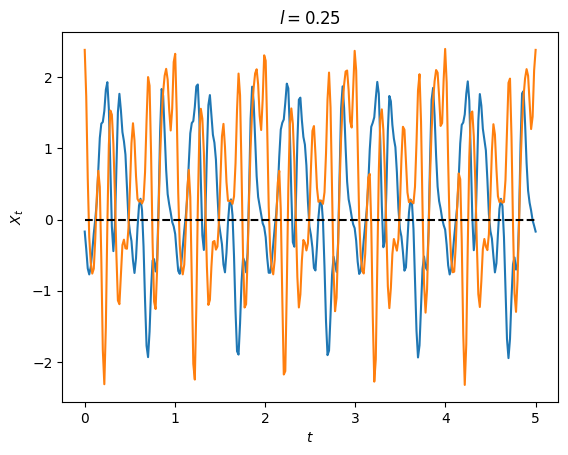

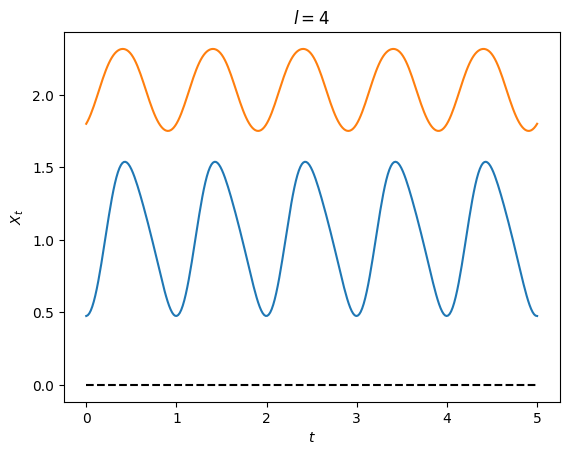

In [ ]:
# COMPLETAR (PARA LA DIAPOSITIVA 72)

#Simulamos los procesos gaussianos variando el l

t = np.linspace(0,5,300)

#l=0.25

muestras = simular_GP_periodic(t,1,0.25,1,2)

plt.plot(t,muestras.T)
plt.plot(t,np.zeros_like(t),color='black',linestyle='--')
plt.title('$l=0.25$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()



#l=4

muestras = simular_GP_periodic(t,1,4,1,2)

plt.plot(t,muestras.T)
plt.plot(t,np.zeros_like(t),color='black',linestyle='--')
plt.title('$l=4$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()



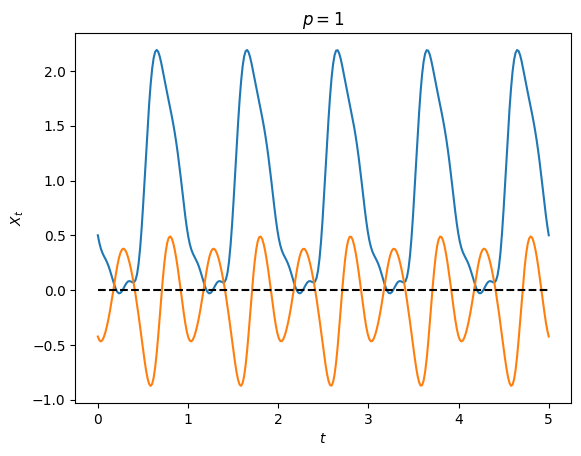

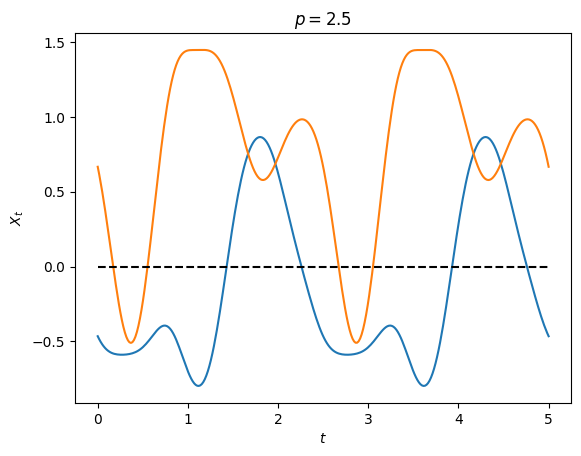

In [ ]:
# COMPLETAR (PARA LA DIAPOSITIVA 74)

#Simulamos los procesos gaussianos variando el p

t = np.linspace(0,5,300)

#p=1

muestras = simular_GP_periodic(t,1,1,1,2)

plt.plot(t,muestras.T)
plt.plot(t,np.zeros_like(t),color='black',linestyle='--')
plt.title('$p=1$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()


#p=2.5

muestras = simular_GP_periodic(t,1,1,2.5,2)

plt.plot(t,muestras.T)
plt.plot(t,np.zeros_like(t),color='black',linestyle='--')
plt.title('$p=2.5$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_455/3413034274.py:13: SyntaxWarning: invalid escape sequence '\s'
  plt.title('$\sigma=1$')
/tmp/ipykernel_455/3413034274.py:25: SyntaxWarning: invalid escape sequence '\s'
  plt.title('$\sigma=4$')


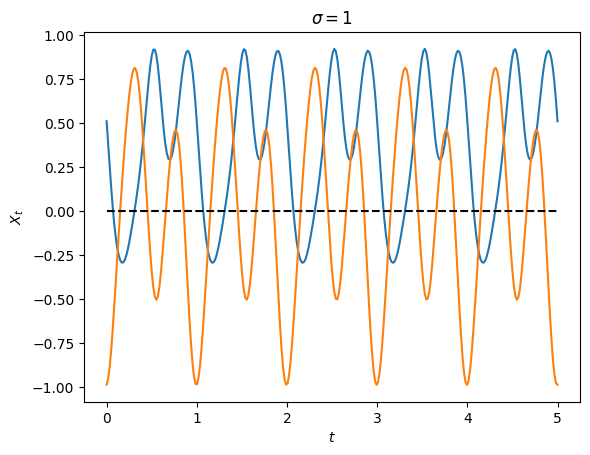

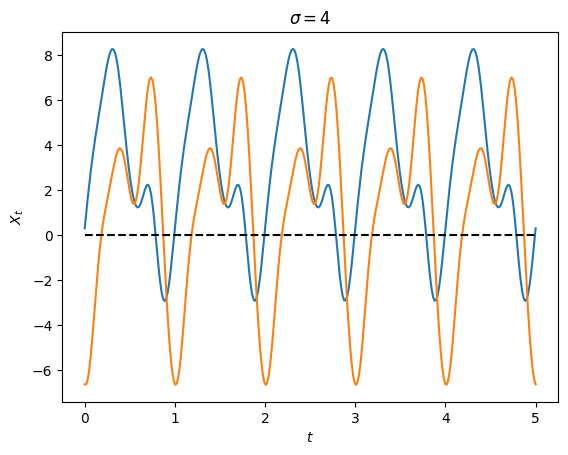

In [ ]:
# COMPLETAR (PARA LA DIAPOSITIVA 76)

#Simulamos los procesos gaussianos variando el sigma

t = np.linspace(0,5,300)

#sigma=1

muestras = simular_GP_periodic(t,1,1,1,2)

plt.plot(t,muestras.T)
plt.plot(t,np.zeros_like(t),color='black',linestyle='--')
plt.title('$\sigma=1$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()


#sigma=4

muestras = simular_GP_periodic(t,4,1,1,2)

plt.plot(t,muestras.T)
plt.plot(t,np.zeros_like(t),color='black',linestyle='--')
plt.title('$\sigma=4$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()

## 4. Simular un GP con kernel DPK (concretamente, polinómico hasta grado $m$)

En esta sección vamos a definir una función `simular_GP_DPKpoly` que nos permita simular de un GP con kernel DPK. Concretamente, un kernel DPK con funciones base $1$, $t$, $\dots$, $t^m$. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [ ]:
# COMPLETAR

def simular_GP_DPKpoly(t, m=1, num_samples=1):
    """
    Simular un GP con kernel polinómico.

    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    m: grado del polinomio. Int.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).
    """
    # Paso 1: calcula el vector de medias. No uses bucles for, puedes usar np.zeros_like

    vector_medias = np.zeros_like(t)

    # Paso 2: calcula la matriz de covarianzas. Vamos a usar un bucle for

    n = len(t)
    F = np.zeros((n, m + 1))
    for i in range(m + 1):
        F[:, i] = t ** i

    matriz_covs = F @ F.T

    # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal

    samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

    return samples

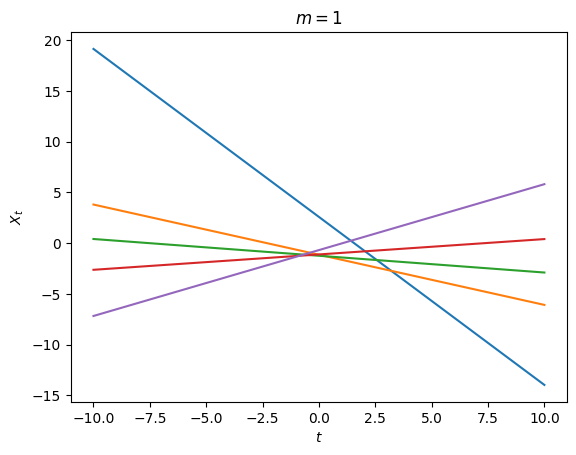

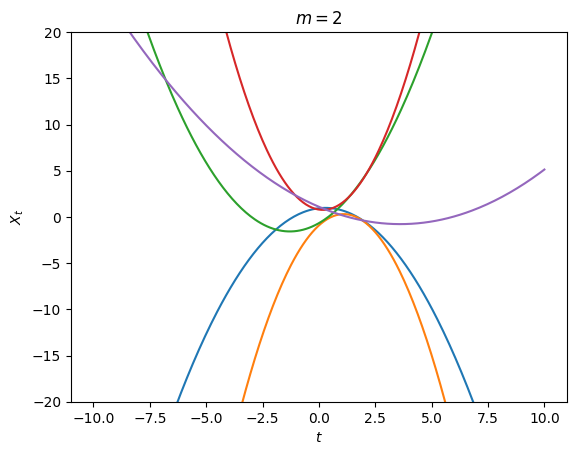

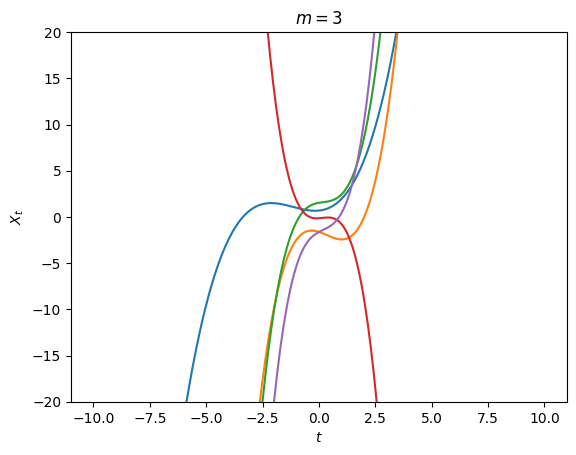

In [ ]:
# COMPLETAR (PARA LA DIAPOSITIVA 89)

#Simulamos los procesos gaussianos variando el grado

t = np.linspace(-10, 10, 300)

#m=1

muestras = simular_GP_DPKpoly(t,1,5)

plt.plot(t,muestras.T)
plt.title('$m=1$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()


#m=2

muestras = simular_GP_DPKpoly(t,2,5)

plt.plot(t,muestras.T)
plt.title('$m=2$')
plt.ylim(-20, 20)       #limitar el eje y a estos valores permite una mejor visualización de las parábolas
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()


#m=3

muestras = simular_GP_DPKpoly(t,3,5)

plt.plot(t,muestras.T)
plt.ylim(-20, 20)
plt.title('$m=3$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.show()
